In [1]:
%load_ext autoreload
%autoreload 2

# Plots of the Data
All plots should be exported as tikz images

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from genpp.plots import RESULTS_DIR

## IFS ENS domain plot
Plot one example forecast

In [6]:
from genpp.data import FORECAST_ENS_PATH

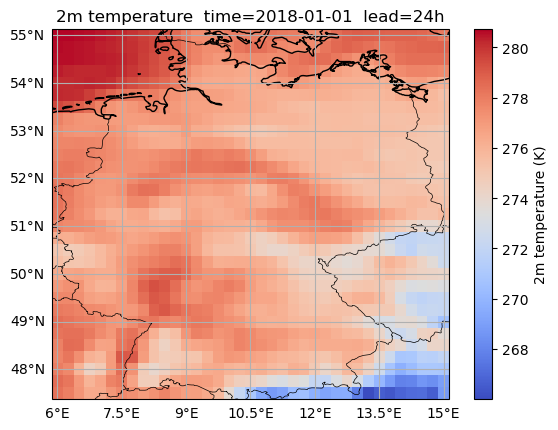

In [7]:
ds = xr.open_dataset(FORECAST_ENS_PATH, engine="zarr")

# choose a sample forecast (change indices or use .sel with a datetime/lead)
sample = ds["2m_temperature"].isel(time=0, number=0, prediction_timedelta=0)

# lat/lon coords (1D)
lon = ds["longitude"]
lat = ds["latitude"]

# extract time and lead info for title
time_val = pd.to_datetime(ds.time.isel(time=0).values).strftime("%Y-%m-%d")
lead_td = ds.prediction_timedelta.isel(prediction_timedelta=0).values
lead_hours = int(lead_td / np.timedelta64(1, "h"))

# compute extent and aspect ratio based on data
lon0, lon1 = float(lon.min()), float(lon.max())
lat0, lat1 = float(lat.min()), float(lat.max())
mean_lat = np.deg2rad((lat0 + lat1) / 2.0)
aspect = (lon1 - lon0) * np.cos(mean_lat) / (lat1 - lat0)

# plot on a map
# set figure size so the plotted box matches the geographic aspect ratio
ax = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(
    lon, lat, sample.values, cmap="coolwarm", transform=ccrs.PlateCarree(), shading="auto"
)

# prefer using an 'equal' aspect in data coordinates; cartopy may ignore this, but the figsize above keeps proportions
ax.set_aspect("auto", adjustable="box")


ax.coastlines(resolution="10m")  # type: ignore
ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # type: ignore
ax.add_feature(cfeature.LAND, facecolor="0.95")  # type: ignore
gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)  # type: ignore
gl.top_labels = gl.right_labels = False
plt.colorbar(pcm, ax=ax, label="2m temperature (K)")
ax.set_title(f"2m temperature  time={time_val}  lead={lead_hours}h")

# pass the figure explicitly so tikzplotlib uses the rendered figure
plt.savefig(RESULTS_DIR / "2m_temp_sample.pdf", bbox_inches="tight")

## ICON Dataset

In [3]:
from genpp.data.icon import DATA_DIR

In [4]:
sample_fc = list((DATA_DIR / "rea").glob("*.nc"))[0]

In [5]:
ds = xr.open_dataset(sample_fc)

In [6]:
time = pd.to_datetime(ds.time.isel(time=0).values).strftime("%Y-%m-%d")

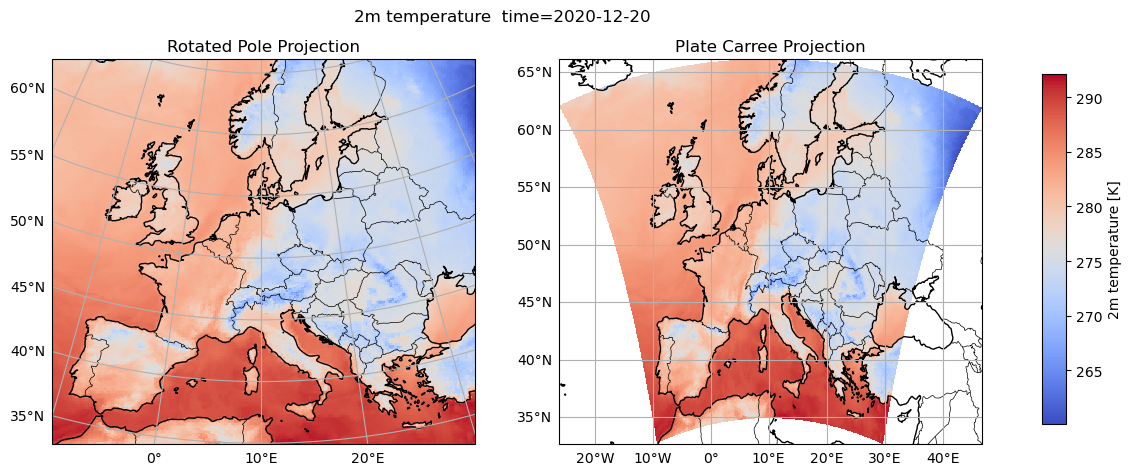

In [7]:
rotated_crs = ccrs.RotatedPole(
    pole_latitude=ds.rotated_pole.grid_north_pole_latitude,
    pole_longitude=ds.rotated_pole.grid_north_pole_longitude,
)

rlon = ds.x
rlat = ds.y
t2m = np.squeeze(ds.T_2M.values)

fig = plt.figure(figsize=(12, 5))
ax1 = plt.subplot(121, projection=rotated_crs)
ax2 = plt.subplot(122, projection=ccrs.PlateCarree())

# Plot data
pcm1 = ax1.pcolormesh(rlon, rlat, t2m, transform=rotated_crs, cmap="coolwarm", shading="auto")
pcm2 = ax2.pcolormesh(rlon, rlat, t2m, transform=rotated_crs, cmap="coolwarm", shading="auto")

# Features
for ax in [ax1, ax2]:
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_aspect("auto", adjustable="box")

# Gridlines
gl = ax1.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)
gl.top_labels = gl.right_labels = False

gl2 = ax2.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False)
gl2.top_labels = gl2.right_labels = False

# Shared colorbar
cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(pcm1, cax=cbar_ax)
cbar.set_label("2m temperature [K]")

ax1.set_title("Rotated Pole Projection")
ax2.set_title("Plate Carree Projection")
plt.suptitle(f"2m temperature  time={time}")
plt.savefig(RESULTS_DIR / "2m_temp_sample_icon_both.pdf", bbox_inches="tight")